###  1_correlation_etf

In [1]:
# !pip install -U rmkf

In [1]:
from rmkf.analyzer import ETFAnalysis

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

class ETFAnalysis:
    def __init__(self, data_store_path):
        self.data_store_path = data_store_path
        self.base_ticker = None
        self.start_date = None
        self.etf_ticker = None
        self.etf_prices = None
        self.monthly_prices = None
        self.risk_free = None
        self.etf_corr_with_baseetf = None
        self.df_corr = pd.DataFrame()
        self.df_rtn = pd.DataFrame()
    

    def set_etf(self, base_ticker, start_date):
        self.base_ticker = base_ticker
        self.start_date = start_date
    
        self._load_etf_data()
        self._load_riskfree_data(year='10')
        self._clean_data()
        self._calculate_monthly_returns()
        self._load_risk_free_rate()
        self._calculate_corr_distribution()
        self._plot_corr_distribution()
        self._calculate_performance()
        
        for i in range(len(self.df_rtn.index)):
            setattr(
                self, 
                f"get_top_etfs_idx{i}", 
                lambda top_n=5, i=i: self._print_and_get_etfs(i, top_n)
            )
        

            
    def _load_etf_data(self):
        # ETF 정보 로딩
        with pd.HDFStore(self.data_store_path, mode='r') as store:
            key = f'us/etfs/symbols/etfdb'
            self.etf_ticker = store[key]
        
        # ETF 가격 로딩
        with pd.HDFStore(self.data_store_path, mode='r') as store:
            key = f'us/etfs/prices/yfinance'
            etf = store[key]
        etf = etf[~etf.index.duplicated()]
        self.etf_prices = etf['close'].unstack('symbol')

    def _load_riskfree_data(self, year='10'):
        # risk_free rate  로딩
        with pd.HDFStore(self.data_store_path, mode='r') as store:
            key = f'us/fund_rate/prices/fred'
            data = store[key]
        data.columns = data.columns.str.lower()
        risk_free = data.filter(like='treasury').filter(like=year).dropna()    
        risk_free = risk_free.droplevel('symbol')
        risk_free.index = pd.to_datetime(risk_free.index)
        self.risk_free = risk_free
 


    
    def _clean_data(self):
        def clean_string(value):
            if isinstance(value, str):
                if value.upper() == 'N/A':  # 'N/A' 처리
                    return np.nan
                value = value.replace('$', '').replace(',', '').replace('%', '')
                try:
                    return float(value)  # 숫자로 변환
                except ValueError:
                    return np.nan  # 변환 실패 시 NaN 반환
            return value

        # ETF 데이터 정리
        self.etf_ticker['total assets ($mm)'] = self.etf_ticker['total assets ($mm)'].apply(clean_string)
        self.etf_ticker['total assets ($mm)'] = self.etf_ticker['total assets ($mm)'].fillna(0).astype(float).astype(int)
        self.etf_ticker['ytd price change(%)'] = (self.etf_ticker['ytd price change'].apply(clean_string).astype(float) / 100)
        self.etf_ticker['avg. daily share volume (3mo)'] = self.etf_ticker['avg. daily share volume (3mo)'].apply(clean_string)
        self.etf_ticker['avg. daily share volume (3mo)'] = self.etf_ticker['avg. daily share volume (3mo)'].fillna(0).astype(float).astype(int)
        self.etf_ticker['previous closing price($)'] = self.etf_ticker['previous closing price'].apply(clean_string).astype(float)
        self.etf_ticker = self.etf_ticker.drop(['previous closing price', 'ytd price change', 'etf database pro', 'watchlist'], axis=1)


    def _calculate_monthly_returns(self):
        prices = self.etf_prices[self.start_date:].dropna(axis=1)
        prices.index = prices.index.map(lambda x: pd.to_datetime(x))
        self.monthly_prices = prices.resample('ME').last()
        base_etf = self.monthly_prices.pct_change()[self.base_ticker]
        self.etf_corr_with_baseetf = self.monthly_prices.pct_change().corrwith(base_etf).sort_values(ascending=False)

    def _load_risk_free_rate(self):
        start_date = self.monthly_prices.index[0]
        end_date = self.monthly_prices.index[-1]
        self.risk_free = self.risk_free[start_date:end_date].resample('ME').last() / 100  # 무위험 수익률

    def _calculate_corr_distribution(self, step=2):
        def filter_corr(df, lower, upper):
            ds = df[(lower < df) & (df <= upper)]
            ds.name = f'({lower}, {upper}]'
            return ds

        # 상관관계 구간 계산
        for i in range(-10, 10, step):
            lower = i / 10
            upper = (i + step) / 10
            filtered_series = filter_corr(self.etf_corr_with_baseetf, lower, upper)
            self.df_corr = pd.concat([self.df_corr, filtered_series], axis=1)


    def _calculate_performance(self):
        # 성과 계산
        for idx in self.df_corr.columns:
            tickers = self.df_corr[idx].dropna().index
            cum_rtn = (
                self.monthly_prices[tickers].pct_change()
                .add(1)
                .cumprod()
                .dropna()
                .tail(1)
                .mean(axis=1)
                .squeeze()
            )
            try:
                mean_std = (
                    self.monthly_prices[tickers].pct_change().dropna().std(axis=1)
                    .mean()
                    .squeeze()
                )
            except:
                mean_std = np.nan

            mean_sharpe = (
                (
                    self.monthly_prices[tickers].pct_change().dropna().mean(axis=1)
                    / self.monthly_prices[tickers].pct_change().dropna().std(axis=1)
                ) - self.risk_free.squeeze()
            ).mean()

            mean_std_df = pd.DataFrame({
                'rtn_cum': [cum_rtn],
                'std': [mean_std],
                'sharpe': [mean_sharpe],
            }, index=[idx])

            self.df_rtn = pd.concat([self.df_rtn, mean_std_df])

    def _sort_by_sharpe_ratio(self):
        self.df_rtn.index.name = 'correlation'
        return self.df_rtn.sort_values(by=['sharpe'], ascending=False)
    
    def _plot_corr_distribution(self):
        # 상관관계 분포 히스토그램
        print(f"{self.base_ticker}와의 상관관계 분포 (ETF 개수 기준)")
        sns.histplot(self.df_corr, palette='tab10')
        plt.show()
        
    def _get_top_etfs(self, idx=0, top_n=5):
        # 샤프 비율이 가장 높은 상관관계 그룹의 ETF 정보
        idx = self.df_rtn.sort_values(by=['sharpe'], ascending=False).index[idx]
        tickers = self.df_corr[idx].dropna().index
        return self.etf_ticker.loc[list(tickers), :] \
            .sort_values(by=['total assets ($mm)', 'avg. daily share volume (3mo)', 'ytd price change(%)'], ascending=False) \
            .head(top_n)


    def _print_and_get_etfs(self, idx, top_n):
        corr_range = self.df_rtn.index[idx].split(',')
        corr_lower= corr_range[0].replace('(','').strip()
        corr_upper= corr_range[1].replace(']','').strip()
        print(f"{self.base_ticker}와 {corr_lower} ~ {corr_upper} 사이의 상관관계를 가진 ETF 목록:")
        return self._get_top_etfs(idx=idx, top_n=top_n)
        


In [41]:
analysis = ETFAnalysis(data_store_path='E:/mlft/data/assets.h5')

GLD와의 상관관계 분포 (ETF 개수 기준)


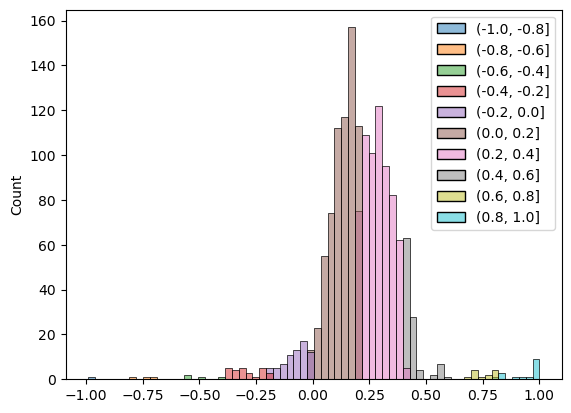

In [43]:
analysis.set_etf(base_ticker='GLD', start_date='2019')

In [46]:
analysis.get_top_etfs_idx1()

GLD와 -0.8 ~ -0.6 사이의 상관관계를 가진 ETF 목록:


,etf name,asset classnew,total assets ($mm),avg. daily share volume (3mo),ytd price change(%),previous closing price($)
symbol,,,,,,
UUP,Invesco DB US Dollar Index Bullish Fund,Currency,322,1375979,-0.0350,28.39
USDU,WisdomTree Bloomberg U.S. Dollar Bullish Fund,Currency,281,511454,-0.0239,27.00
EUO,ProShares UltraShort Euro,Currency,33,34485,-0.0893,31.80
YCS,ProShares UltraShort Yen,Currency,21,10770,-0.0709,43.37


In [47]:
analysis.get_top_etfs_idx2()

GLD와 -0.6 ~ -0.4 사이의 상관관계를 가진 ETF 목록:


,etf name,asset classnew,total assets ($mm),avg. daily share volume (3mo),ytd price change(%),previous closing price($)
symbol,,,,,,
VTI,Vanguard Total Stock Market ETF,Equity,440474,3591115,-0.0442,276.99
QQQ,Invesco QQQ Trust Series I,Equity,301058,36571055,-0.0618,479.66
VUG,Vanguard Growth ETF,Equity,145031,1428649,-0.0782,378.33
VTV,Vanguard Value ETF,Equity,130996,2593687,0.0118,171.30
IWF,iShares Russell 1000 Growth ETF,Equity,96518,1637248,-0.0806,369.20


In [48]:
analysis.get_top_etfs_idx3()

GLD와 -0.4 ~ -0.2 사이의 상관관계를 가진 ETF 목록:


,etf name,asset classnew,total assets ($mm),avg. daily share volume (3mo),ytd price change(%),previous closing price($)
symbol,,,,,,
SPY,SPDR S&P 500 ETF Trust,Equity,600614,56448801,-0.0397,562.81
VOO,Vanguard S&P 500 ETF,Equity,594751,6926426,-0.0396,517.46
IVV,iShares Core S&P 500 ETF,Equity,556380,7362918,-0.0393,565.56
VEA,Vanguard FTSE Developed Markets ETF,Equity,145064,13230992,0.0916,52.20
IEFA,iShares Core MSCI EAFE ETF,Equity,128314,10693864,0.1043,77.61


In [49]:
analysis.get_top_etfs_idx4()

GLD와 -0.2 ~ 0.0 사이의 상관관계를 가진 ETF 목록:


,etf name,asset classnew,total assets ($mm),avg. daily share volume (3mo),ytd price change(%),previous closing price($)
symbol,,,,,,
BND,Vanguard Total Bond Market ETF,Bond,126902,6939282,0.0208,72.95
AGG,iShares Core U.S. Aggregate Bond ETF,Bond,124697,8502787,0.0207,98.28
VCIT,Vanguard Intermediate-Term Corporate Bond ETF,Bond,50522,6932303,0.0177,81.09
VCSH,Vanguard Short-Term Corporate Bond ETF,Bond,34505,4022644,0.0131,78.49
BSV,Vanguard Short-Term Bond ETF,Bond,34342,2158851,0.0140,77.88


In [50]:
analysis.get_top_etfs_idx5()

GLD와 0.0 ~ 0.2 사이의 상관관계를 가진 ETF 목록:


,etf name,asset classnew,total assets ($mm),avg. daily share volume (3mo),ytd price change(%),previous closing price($)
symbol,,,,,,
SLV,iShares Silver Trust,Commodity,14381,19205047,0.1664,30.71
SIVR,abrdn Physical Silver Shares ETF,Commodity,1582,624811,0.1672,32.18
SIL,Global X Silver Miners ETF,Equity,1377,896915,0.2471,39.62
SILJ,Amplify Junior Silver Miners ETF,Equity,1053,2898954,0.2367,12.28
AGQ,ProShares Ultra Silver,Commodity,709,1826507,0.3365,45.00


In [51]:
analysis.get_top_etfs_idx6()

GLD와 0.2 ~ 0.4 사이의 상관관계를 가진 ETF 목록:


,etf name,asset classnew,total assets ($mm),avg. daily share volume (3mo),ytd price change(%),previous closing price($)
symbol,,,,,,
XLE,Energy Select Sector SPDR Fund,Equity,31742,16053857,0.0479,89.76
VDE,Vanguard Energy ETF,Equity,7400,493715,0.0253,124.38
KRE,SPDR S&P Regional Banking ETF,Equity,3477,12873323,-0.0595,56.76
DXJ,WisdomTree Japan Hedged Equity Fund,Equity,3433,461425,0.0084,111.22
SQQQ,ProShares UltraPro Short QQQ,Equity,2223,63236719,0.1795,36.73


In [52]:
analysis.get_top_etfs_idx7()

GLD와 0.4 ~ 0.6 사이의 상관관계를 가진 ETF 목록:


,etf name,asset classnew,total assets ($mm),avg. daily share volume (3mo),ytd price change(%),previous closing price($)
symbol,,,,,,
SH,ProShares Short S&P500,Equity,1247,5557331,0.0529,44.62
SPXU,ProShares UltraPro Short S&P500,Equity,513,12490063,0.1340,25.55
UNG,United States Natural Gas Fund LP,Commodity,415,9638152,0.2963,21.79
SDS,ProShares UltraShort S&P500,Equity,412,14002833,0.0946,21.53
SPXS,Direxion Daily S&P 500 Bear 3X Shares,Equity,410,74996703,0.1369,7.14


In [53]:
analysis.get_top_etfs_idx8()

GLD와 0.6 ~ 0.8 사이의 상관관계를 가진 ETF 목록:


,etf name,asset classnew,total assets ($mm),avg. daily share volume (3mo),ytd price change(%),previous closing price($)
symbol,,,,,,
DUST,Direxion Daily Gold Miners Index Bear 2x Shares,Equity,88,864720,-0.4096,40.60
JDST,Direxion Daily Junior Gold Miners Index Bear 2...,Equity,51,933977,-0.4237,17.79
ZSL,ProShares UltraShort Silver,Commodity,27,397549,-0.2783,30.31


In [54]:
analysis.get_top_etfs_idx9()

GLD와 0.8 ~ 1.0 사이의 상관관계를 가진 ETF 목록:


,etf name,asset classnew,total assets ($mm),avg. daily share volume (3mo),ytd price change(%),previous closing price($)
symbol,,,,,,
GLL,ProShares UltraShort Gold,Commodity,29,384595,-0.2127,13.84


---